## Supervised learning approach to estimate probability of default (PD)

Here we implement a simple 2-layered neural network (NN) to estimate the probability of default given a data set

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## The data

In order to provide reproducible, I will rely on the data from Kaggle competition Give Me Some Credit (https://www.kaggle.com/c/GiveMeSomeCredit).

In [2]:
# We load & prepare data (Give Me Some Credit) =====
# Put the CSV at: data/cs-training.csv
df = pd.read_csv("data/GiveMeSomeCredit/cs-training.csv", index_col = 0)

# Target and features
y_all = df["SeriousDlqin2yrs"].values.reshape(-1, 1)  # (N,1)
X_all = df.drop(columns=["SeriousDlqin2yrs"])
X_all = X_all.select_dtypes(include=[np.number]).values  # we keep numeric only

rng = np.random.default_rng(0)

We check how 'incomplete' the data is

In [3]:
X_df = df.drop(columns=["SeriousDlqin2yrs"], errors="ignore")

# number of rows with ≥1 NaN
n_rows_with_nan = X_df.isna().any(axis=1).sum() # Here we count the number of rows with at least one NaN
n_rows_total = len(X_df)

print(n_rows_with_nan, "rows with at least one NaN")
print(f"{n_rows_with_nan/n_rows_total:.2%} of rows")

29731 rows with at least one NaN
19.82% of rows


## Input
We clean the data first. There are some data points that contain NaN. We use imputer and scaler functions of sci-kit learn to set those NaN to the median value of a given array.

In [4]:
# Impute missing with median, then standardize

imputer = SimpleImputer(strategy="median") #Since the NaNs are undefined, we use the scikit function to replace the value with the median of that column (as a vector)
scaler  = StandardScaler()

X_all = imputer.fit_transform(X_all) #replaces any entry NaN with the median of the of the corresponding column

X_all = scaler.fit_transform(X_all) #rescale each column as x_j->(x_j-mu)/sigma (where sigma and mu correspond to that column)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

#stratify : we split the data in two sets (training and validation). Stratify ensures that both have the same shares of defaults

## The model 

I use a simple neural network activated via ReLu followed by a sigmoid. I also define a forward, entropy loss function and backward propagation (gradient descent).

In [6]:
# =====  Activation functions =====
def relu(Z):
    return np.maximum(0.0, Z)

def sigmoid(Z):
    # numerically stable enough for this use
    return 1.0 / (1.0 + np.exp(-Z))

# ===== 2) He initialization (for ReLU) =====
def he_init(d, H, rng):
    W1 = rng.normal(0.0, np.sqrt(2.0/d), size=(d, H))
    b1 = np.zeros((1, H))
    W2 = rng.normal(0.0, np.sqrt(2.0/H), size=(H, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2

# ===== 3) Forward pass =====
def forward(X, W1, b1, W2, b2):
    # X: (N, d)
    Z1 = X @ W1 + b1            # (N, H) affine
    A1 = relu(Z1)               # (N, H) nonlinearity
    Z2 = A1 @ W2 + b2           # (N, 1) logit
    Yhat = sigmoid(Z2)          # (N, 1) probability
    cache = (Z1, A1, Z2, Yhat)  # we need these for backprop
    return Yhat, cache

# ===== 4) Binary cross-entropy loss (mean over batch) =====
def bce_loss(Yhat, y, eps=1e-12):
    Yhat = np.clip(Yhat, eps, 1.0 - eps)
    return -(y * np.log(Yhat) + (1 - y) * np.log(1 - Yhat)).mean()

# ===== 5) Backward pass (gradients via chain rule) =====
def backward(X, y, cache, W2):
    Z1, A1, Z2, Yhat = cache
    N = X.shape[0]
    G2 = (Yhat - y) / N               # (N, 1) output error
    dW2 = A1.T @ G2                   # (H, 1)
    db2 = np.sum(G2, axis=0, keepdims=True)   # (1, 1)
    G1 = (G2 @ W2.T) * (Z1 > 0)       # (N, H) elementwise mask for ReLU
    dW1 = X.T @ G1                    # (d, H)
    db1 = np.sum(G1, axis=0, keepdims=True)   # (1, H)
    return dW1, db1, dW2, db2

## Initialize training

In [7]:
# ===== Training loop (mini-batch SGD) with loss history =====

# Define dimensions consistently here (no hard-coding)
d = X_train.shape[1]   # number of features, ie, number of columns
H = 64                 # hidden units (you can try 32 or 128 later)

W1, b1, W2, b2 = he_init(d, H, rng) #We define W1, b1, W2, b2 of the two layered network

train_hist, val_hist = [], []  # store loss per epoch

epochs = 1000
batch_size = 256
lr = 1e-3

n_train = X_train.shape[0]
for ep in range(1, epochs + 1):
    # shuffle indices for this epoch
    idx = rng.permutation(n_train)

    # iterate over mini-batches by index (no in-place array shuffling)
    for start in range(0, n_train, batch_size):
        stop = min(start + batch_size, n_train)
        bidx = idx[start:stop]
        Xb = X_train[bidx]
        yb = y_train[bidx]

        # forward -> loss
        Yhat_b, cache_b = forward(Xb, W1, b1, W2, b2)
        loss_b = bce_loss(Yhat_b, yb)

        # backward -> grads
        dW1, db1, dW2, db2 = backward(Xb, yb, cache_b, W2)

        # SGD update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    # end-epoch: evaluate full train/val loss
    train_pred, _ = forward(X_train, W1, b1, W2, b2)
    val_pred, _   = forward(X_val,   W1, b1, W2, b2)
    train_loss = bce_loss(train_pred, y_train)
    val_loss   = bce_loss(val_pred,   y_val)

    # record for plotting
    train_hist.append(train_loss)
    val_hist.append(val_loss)

    # print every 5 epochs (or first)
    if ep % 5 == 0 or ep == 1:
        print(f"epoch {ep:02d} | train={train_loss:.4f} | val={val_loss:.4f}")

epoch 01 | train=0.3995 | val=0.4020
epoch 05 | train=0.2822 | val=0.2844
epoch 10 | train=0.2551 | val=0.2566
epoch 15 | train=0.2491 | val=0.2504
epoch 20 | train=0.2454 | val=0.2463
epoch 25 | train=0.2424 | val=0.2431
epoch 30 | train=0.2398 | val=0.2402
epoch 35 | train=0.2375 | val=0.2377
epoch 40 | train=0.2354 | val=0.2354
epoch 45 | train=0.2335 | val=0.2333
epoch 50 | train=0.2317 | val=0.2313
epoch 55 | train=0.2300 | val=0.2296
epoch 60 | train=0.2285 | val=0.2279
epoch 65 | train=0.2270 | val=0.2263
epoch 70 | train=0.2256 | val=0.2249
epoch 75 | train=0.2244 | val=0.2235
epoch 80 | train=0.2232 | val=0.2223
epoch 85 | train=0.2220 | val=0.2211
epoch 90 | train=0.2209 | val=0.2199
epoch 95 | train=0.2199 | val=0.2189
epoch 100 | train=0.2189 | val=0.2179
epoch 105 | train=0.2180 | val=0.2169
epoch 110 | train=0.2171 | val=0.2160
epoch 115 | train=0.2163 | val=0.2151
epoch 120 | train=0.2155 | val=0.2143
epoch 125 | train=0.2147 | val=0.2135
epoch 130 | train=0.2140 | val=0

## Plotting

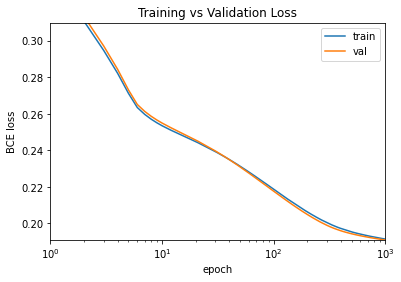

In [8]:
# ===== Plot the loss curves =====
plt.figure()

plt.plot(train_hist, label="train")
plt.plot(val_hist, label="val")
plt.xscale("log")        

ymin = min(min(train_hist), min(val_hist))
ymax = max(max(train_hist), max(val_hist))

plt.ylim(ymin , 0.31 )   # ← AFTER plotting
plt.xlim(1 , epochs )   # ← AFTER plotting


plt.xlabel("epoch")
plt.ylabel("BCE loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

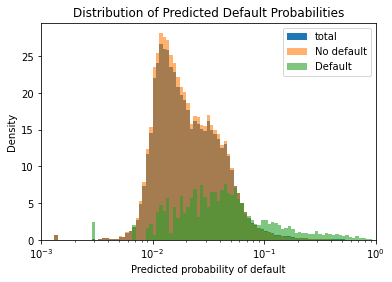

In [9]:
probs_val = forward(X_val, W1, b1, W2, b2)[0]
probs_default    = probs_val[y_val.ravel() == 1]
probs_nondefault = probs_val[y_val.ravel() == 0]

probs = probs_val.ravel()

plt.figure()

plt.hist(probs, bins=np.logspace(-3, 0, 100), density=True, label="total")

plt.hist(probs_nondefault, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="No default")

plt.hist(probs_default, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="Default")

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")

plt.xscale("log")   
plt.xlim(10**(-3) , 1 )  
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()

plt.show()

In [10]:
bins = np.logspace(-3, 0, 35)
bin_ids = np.digitize(probs, bins)

bin_centers = []
obs_rates = []
counts = []
deviation = []
uncertainty = []
standarized_discr = []

for i in range(1, len(bins)):
    mask = bin_ids == i
    if mask.sum() > 50:   # avoid tiny bins
        pi = np.sqrt(bins[i-1]*bins[i])
        ri = y_val[mask].mean()
        ni = mask.sum()
        deltai = ri - pi
        sigmai = np.sqrt(pi*(1-pi)/ni  )
        
        bin_centers.append( pi )
        obs_rates.append( ri )

        deviation.append( deltai )
        uncertainty.append( sigmai )
        standarized_discr.append( deltai/sigmai )
        counts.append( ni )
        
        #print(y_val[mask].mean())
        #print("center is", np.sqrt(bins[i-1]*bins[i]))
        #print("bin(i-1) is ", bins[i-1])
        #print("bin(i) is ", bins[i])
        #print("average is ", (bins[i]+bins[i-1])/2)


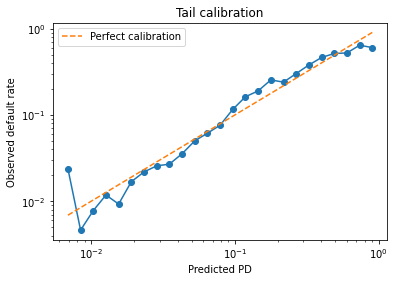

In [11]:
plt.figure()
plt.plot(bin_centers, obs_rates, "o-")
plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.legend()
plt.title("Tail calibration")
plt.show()


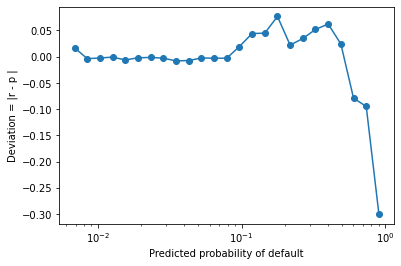

In [12]:
plt.figure()
plt.plot(bin_centers,deviation, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("Deviation = |r - p |")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

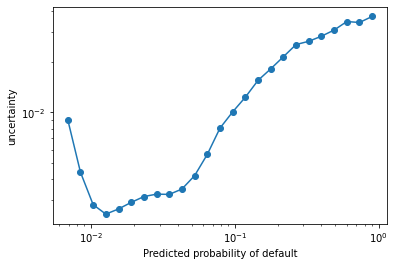

In [13]:
plt.figure()
plt.plot(bin_centers,uncertainty, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("uncertainty")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

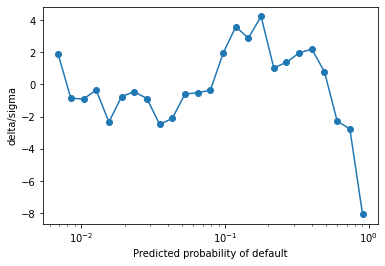

In [14]:
plt.figure()
plt.plot(bin_centers,standarized_discr, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("delta/sigma")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

## We now plot the Receiver Operating Characteristic (ROC) curve

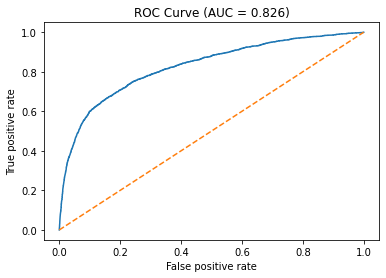

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

y_true = y_val.ravel()
y_score = probs

# ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
auc_roc = roc_auc_score(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC Curve (AUC = {auc_roc:.3f})")
plt.show()


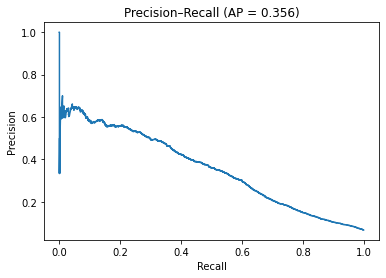

In [16]:
# Precision recall
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall (AP = {ap:.3f})")
plt.show()

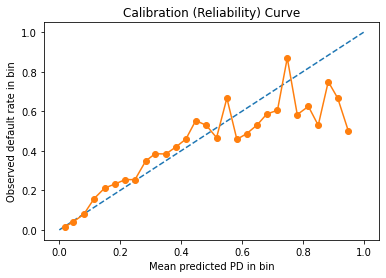

In [17]:
def calib_curve(y_true, y_prob, n_bins=30):
    bins = np.linspace(0, 1, n_bins+1)
    idx = np.digitize(y_prob, bins) - 1
    frac_pos, mean_pred = [], []
    for b in range(n_bins):
        mask = (idx == b)
        if mask.any():
            frac_pos.append(y_true[mask].mean())
            mean_pred.append(y_prob[mask].mean())
    return np.array(mean_pred), np.array(frac_pos)

mp, fp = calib_curve(y_true, y_score, n_bins=30)
plt.figure()
plt.plot([0,1],[0,1],'--')
plt.plot(mp, fp, marker='o')
plt.xlabel("Mean predicted PD in bin")
plt.ylabel("Observed default rate in bin")
plt.title("Calibration (Reliability) Curve")
plt.show()

# TensorFlow implementation
Let's do the same exercise using established libraries

In [18]:
import numpy as np
import tensorflow as tf

# Ensure float32 for TF
X_train_tf = X_train.astype(np.float32)
X_val_tf   = X_val.astype(np.float32)

# Ensure labels are float32 shape (N,1)
y_train_tf = y_train.astype(np.float32).reshape(-1, 1)
y_val_tf   = y_val.astype(np.float32).reshape(-1, 1)

d = X_train_tf.shape[1]
H = 64

# Model: (d -> H ReLU) -> (H -> 1 Sigmoid)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(d,)),
    tf.keras.layers.Dense( # this is the first layer
        H,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal()), #HeNormal initializes Wi's and b's with gaussian noise
    tf.keras.layers.Dense(1, activation="sigmoid") #second layer
])

# Compile: BCE + Adam optimizer
lr = 1e-3
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=tf.keras.losses.BinaryCrossentropy(), #we use the binary cross entropy
    metrics=[tf.keras.metrics.AUC(name="auc_roc", curve="ROC"),
             tf.keras.metrics.AUC(name="auc_pr", curve="PR")]
)

# Train
history = model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=200,
    batch_size=256,
    verbose=1
)

# Predict probabilities (like in forward(...))
probs_val_tf = model.predict(X_val_tf, batch_size=4096).ravel()


2026-02-03 14:34:02.474476: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 14:34:03.314932: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Epoch 1/200


2026-02-03 14:34:04.104799: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-03 14:34:04.169182: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


469/469 [==============================] - 1s 1ms/step - loss: 0.3197 - auc_roc: 0.5787 - auc_pr: 0.0798 - val_loss: 0.2281 - val_auc_roc: 0.7006 - val_auc_pr: 0.2280
Epoch 2/200
469/469 [==============================] - 0s 975us/step - loss: 0.2151 - auc_roc: 0.7519 - auc_pr: 0.2763 - val_loss: 0.2034 - val_auc_roc: 0.7946 - val_auc_pr: 0.3174
Epoch 3/200
469/469 [==============================] - 0s 956us/step - loss: 0.1989 - auc_roc: 0.8034 - auc_pr: 0.3242 - val_loss: 0.1940 - val_auc_roc: 0.8187 - val_auc_pr: 0.3418
Epoch 4/200
469/469 [==============================] - 0s 956us/step - loss: 0.1932 - auc_roc: 0.8186 - auc_pr: 0.3406 - val_loss: 0.1913 - val_auc_roc: 0.8273 - val_auc_pr: 0.3506
Epoch 5/200
469/469 [==============================] - 0s 960us/step - loss: 0.1912 - auc_roc: 0.8241 - auc_pr: 0.3508 - val_loss: 0.1913 - val_auc_roc: 0.8287 - val_auc_pr: 0.3517
Epoch 6/200
469/469 [==============================] - 0s 960us/step - loss: 0.1906 - auc_roc: 0.8262 - auc_p

469/469 [==============================] - 0s 958us/step - loss: 0.1861 - auc_roc: 0.8361 - auc_pr: 0.3762 - val_loss: 0.1868 - val_auc_roc: 0.8379 - val_auc_pr: 0.3685
Epoch 47/200
469/469 [==============================] - 0s 965us/step - loss: 0.1860 - auc_roc: 0.8361 - auc_pr: 0.3782 - val_loss: 0.1867 - val_auc_roc: 0.8369 - val_auc_pr: 0.3694
Epoch 48/200
469/469 [==============================] - 0s 974us/step - loss: 0.1860 - auc_roc: 0.8363 - auc_pr: 0.3761 - val_loss: 0.1868 - val_auc_roc: 0.8380 - val_auc_pr: 0.3664
Epoch 49/200
469/469 [==============================] - 0s 954us/step - loss: 0.1859 - auc_roc: 0.8365 - auc_pr: 0.3768 - val_loss: 0.1868 - val_auc_roc: 0.8383 - val_auc_pr: 0.3679
Epoch 50/200
469/469 [==============================] - 0s 978us/step - loss: 0.1859 - auc_roc: 0.8363 - auc_pr: 0.3788 - val_loss: 0.1867 - val_auc_roc: 0.8381 - val_auc_pr: 0.3666
Epoch 51/200
469/469 [==============================] - 0s 958us/step - loss: 0.1859 - auc_roc: 0.8358 

469/469 [==============================] - 0s 964us/step - loss: 0.1850 - auc_roc: 0.8397 - auc_pr: 0.3803 - val_loss: 0.1879 - val_auc_roc: 0.8377 - val_auc_pr: 0.3660
Epoch 92/200
469/469 [==============================] - 0s 954us/step - loss: 0.1847 - auc_roc: 0.8400 - auc_pr: 0.3840 - val_loss: 0.1871 - val_auc_roc: 0.8397 - val_auc_pr: 0.3666
Epoch 93/200
469/469 [==============================] - 0s 940us/step - loss: 0.1849 - auc_roc: 0.8396 - auc_pr: 0.3822 - val_loss: 0.1875 - val_auc_roc: 0.8405 - val_auc_pr: 0.3642
Epoch 94/200
469/469 [==============================] - 0s 951us/step - loss: 0.1847 - auc_roc: 0.8400 - auc_pr: 0.3843 - val_loss: 0.1861 - val_auc_roc: 0.8404 - val_auc_pr: 0.3663
Epoch 95/200
469/469 [==============================] - 0s 946us/step - loss: 0.1848 - auc_roc: 0.8397 - auc_pr: 0.3821 - val_loss: 0.1865 - val_auc_roc: 0.8388 - val_auc_pr: 0.3714
Epoch 96/200
469/469 [==============================] - 0s 957us/step - loss: 0.1847 - auc_roc: 0.8399 

Epoch 136/200
469/469 [==============================] - 0s 952us/step - loss: 0.1838 - auc_roc: 0.8432 - auc_pr: 0.3870 - val_loss: 0.1858 - val_auc_roc: 0.8416 - val_auc_pr: 0.3729
Epoch 137/200
469/469 [==============================] - 0s 970us/step - loss: 0.1837 - auc_roc: 0.8432 - auc_pr: 0.3893 - val_loss: 0.1858 - val_auc_roc: 0.8416 - val_auc_pr: 0.3713
Epoch 138/200
469/469 [==============================] - 0s 967us/step - loss: 0.1838 - auc_roc: 0.8431 - auc_pr: 0.3872 - val_loss: 0.1855 - val_auc_roc: 0.8429 - val_auc_pr: 0.3707
Epoch 139/200
469/469 [==============================] - 0s 944us/step - loss: 0.1838 - auc_roc: 0.8430 - auc_pr: 0.3878 - val_loss: 0.1859 - val_auc_roc: 0.8419 - val_auc_pr: 0.3693
Epoch 140/200
469/469 [==============================] - 0s 952us/step - loss: 0.1839 - auc_roc: 0.8434 - auc_pr: 0.3859 - val_loss: 0.1859 - val_auc_roc: 0.8416 - val_auc_pr: 0.3715
Epoch 141/200
469/469 [==============================] - 0s 955us/step - loss: 0.1838

Epoch 181/200
469/469 [==============================] - 0s 972us/step - loss: 0.1827 - auc_roc: 0.8468 - auc_pr: 0.3930 - val_loss: 0.1852 - val_auc_roc: 0.8456 - val_auc_pr: 0.3726
Epoch 182/200
469/469 [==============================] - 0s 952us/step - loss: 0.1826 - auc_roc: 0.8468 - auc_pr: 0.3929 - val_loss: 0.1850 - val_auc_roc: 0.8457 - val_auc_pr: 0.3703
Epoch 183/200
469/469 [==============================] - 0s 961us/step - loss: 0.1826 - auc_roc: 0.8472 - auc_pr: 0.3918 - val_loss: 0.1843 - val_auc_roc: 0.8476 - val_auc_pr: 0.3719
Epoch 184/200
469/469 [==============================] - 0s 955us/step - loss: 0.1826 - auc_roc: 0.8475 - auc_pr: 0.3915 - val_loss: 0.1849 - val_auc_roc: 0.8450 - val_auc_pr: 0.3756
Epoch 185/200
469/469 [==============================] - 0s 975us/step - loss: 0.1826 - auc_roc: 0.8472 - auc_pr: 0.3914 - val_loss: 0.1858 - val_auc_roc: 0.8442 - val_auc_pr: 0.3686
Epoch 186/200
469/469 [==============================] - 0s 948us/step - loss: 0.1824

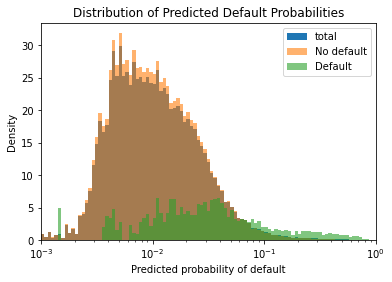

In [19]:
probs_default_tf    = probs_val_tf[y_val_tf.ravel() == 1]
probs_nondefault_tf = probs_val_tf[y_val_tf.ravel() == 0]

probs_tf = probs_val_tf.ravel()

plt.figure()

plt.hist(probs_tf, bins=np.logspace(-3, 0, 100), density=True, label="total")

plt.hist(probs_nondefault_tf, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="No default")

plt.hist(probs_default_tf, bins=np.logspace(-3, 0, 100), density=True,
         alpha=0.6, label="Default")

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")

plt.xscale("log")   
plt.xlim(10**(-3) , 1 )  
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()

plt.show()

In [20]:
bins = np.logspace(-3, 0, 35)
bin_ids = np.digitize(probs_tf, bins)

bin_centers_tf = []
obs_rates_tf = []
counts_tf = []
deviation_tf = []
uncertainty_tf = []
standarized_discr_tf = []

for i in range(1, len(bins)):
    mask = bin_ids == i
    if mask.sum() > 50:   # avoid tiny bins
        pi = np.sqrt(bins[i-1]*bins[i])
        ri = y_val_tf[mask].mean()
        ni = mask.sum()
        deltai = ri - pi
        sigmai = np.sqrt(pi*(1-pi)/ni  )
        
        bin_centers_tf.append( pi )
        obs_rates_tf.append( ri )

        deviation_tf.append( deltai )
        uncertainty_tf.append( sigmai )
        standarized_discr_tf.append( deltai/sigmai )
        counts_tf.append( ni )
        
        #print(y_val[mask].mean())
        #print("center is", np.sqrt(bins[i-1]*bins[i]))
        #print("bin(i-1) is ", bins[i-1])
        #print("bin(i) is ", bins[i])
        #print("average is ", (bins[i]+bins[i-1])/2)

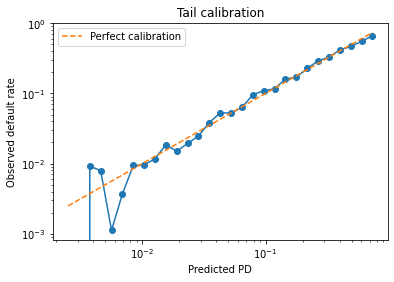

In [21]:
plt.figure()
plt.plot(bin_centers_tf, obs_rates_tf, "o-")
plt.plot(bin_centers_tf, bin_centers_tf, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.legend()
plt.title("Tail calibration")
plt.show()

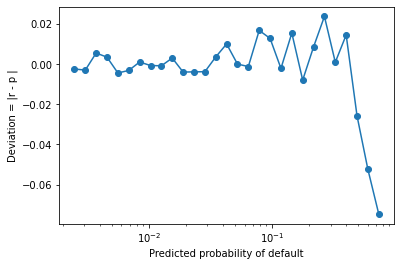

In [22]:
plt.figure()
plt.plot(bin_centers_tf,deviation_tf, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("Deviation = |r - p |")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

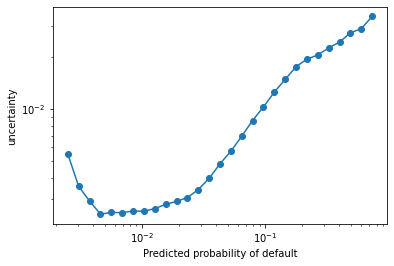

In [23]:
plt.figure()
plt.plot(bin_centers_tf,uncertainty_tf, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("uncertainty")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()

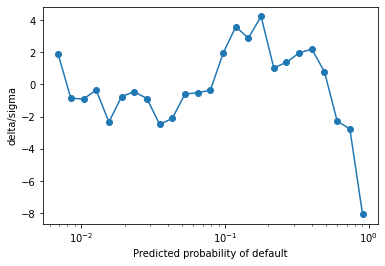

In [24]:
plt.figure()
plt.plot(bin_centers,standarized_discr, "o-")
#plt.plot(bin_centers, bin_centers, "--", label="Perfect calibration")
plt.xscale("log")
#plt.yscale("log")
plt.xlabel("Predicted probability of default")
plt.ylabel("delta/sigma")
#plt.title("Deviation = |r - p | ")

#plt.legend()

plt.show()